CIFAR-**10**

In [11]:
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt
import numpy as np

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)


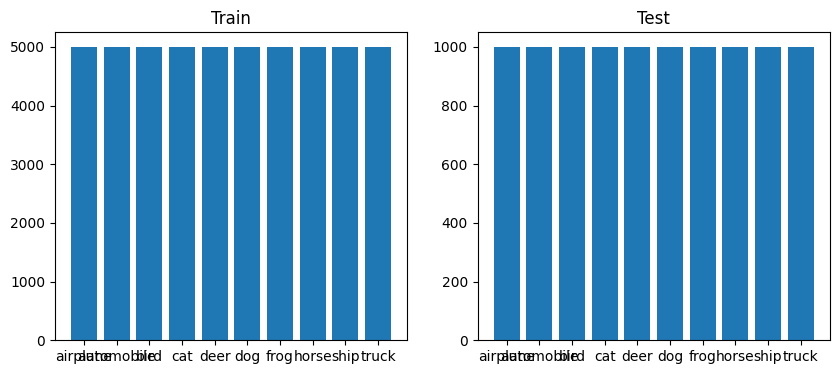

In [12]:
classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
train_counts = np.bincount(y_train.flatten())
test_counts = np.bincount(y_test.flatten())
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(classes, train_counts)
ax[0].set_title("Train")
ax[1].bar(classes, test_counts)
ax[1].set_title("Test")
plt.show()

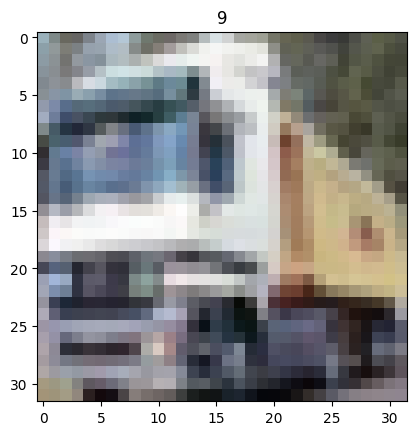

In [13]:
plt.imshow(X_train[1])
plt.title(y_train[1][0])
plt.show()

In [14]:
import math
math.exp(1000)

OverflowError: math range error

In [15]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [16]:
from tensorflow.keras.utils import to_categorical
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPooling2D

In [19]:
model_0 = Sequential()
model_0.add(Conv2D(32, (3, 3),activation = 'relu', padding='same', input_shape=(32, 32, 3)))
model_0.add(MaxPooling2D((2, 2)))
model_0.add(Conv2D(32, (3, 3), activation = 'relu', padding='same'))
model_0.add(MaxPooling2D((2, 2)))
model_0.add(Conv2D(32, (3, 3),activation = 'relu', padding='same'))
model_0.add(MaxPooling2D((2, 2)))
model_0.add(Flatten())
model_0.add(Dense(128, activation='relu'))
model_0.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model_0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,346 (337.29 KB)

 Trainable params: 86,346 (337.29 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model_0.compile(loss='categorical_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

In [22]:
history_0 = model_0.fit(X_train, y_train_cat,
                        epochs=10,
                        validation_data=(X_test, y_test_cat))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.4526 - loss: 1.5028 - val_accuracy: 0.5556 - val_loss: 1.2326
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5980 - loss: 1.1306 - val_accuracy: 0.6234 - val_loss: 1.0582
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6548 - loss: 0.9748 - val_accuracy: 0.6652 - val_loss: 0.9540
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6923 - loss: 0.8746 - val_accuracy: 0.6710 - val_loss: 0.9391
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7231 - loss: 0.7953 - val_accuracy: 0.6956 - val_loss: 0.8634
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7382 - loss: 0.7412 - val_accuracy: 0.7165 - val_loss: 0.8206
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7556 - loss: 0.6948 - val_accuracy: 0.7162 - val_loss: 0.8132
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7711 - loss: 0.6492

In [23]:
history_1 = model_0.fit(X_train, y_train_cat,
                        epochs=10,
                        batch_size=64,
                        validation_data=(X_test, y_test_cat))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8335 - loss: 0.4721 - val_accuracy: 0.7354 - val_loss: 0.8020
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8413 - loss: 0.4521 - val_accuracy: 0.7324 - val_loss: 0.8315
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8453 - loss: 0.4349 - val_accuracy: 0.7296 - val_loss: 0.8320
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8506 - loss: 0.4199 - val_accuracy: 0.7163 - val_loss: 0.9093
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8583 - loss: 0.3955 - val_accuracy: 0.7374 - val_loss: 0.8653
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8702 - loss: 0.3702 - val_accuracy: 0.7299 - val_loss: 0.9171
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8773 - loss: 0.3464 - val_accuracy: 0.7349 - val_loss: 0.9207
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8797 - loss: 0.3321 - val_accuracy: 0.

In [24]:
test_loss, test_accuracy = model_0.evaluate(X_test, y_test_cat)
print(f"Test accuracy: {test_accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7261 - loss: 1.0827
Test accuracy: 0.7261000275611877


In [26]:
y_perdicted = model_0.predict(X_test)
y_perdicted_classes = np.argmax(y_perdicted, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [27]:
y_perdicted_classes

array([5, 8, 8, ..., 5, 4, 7])

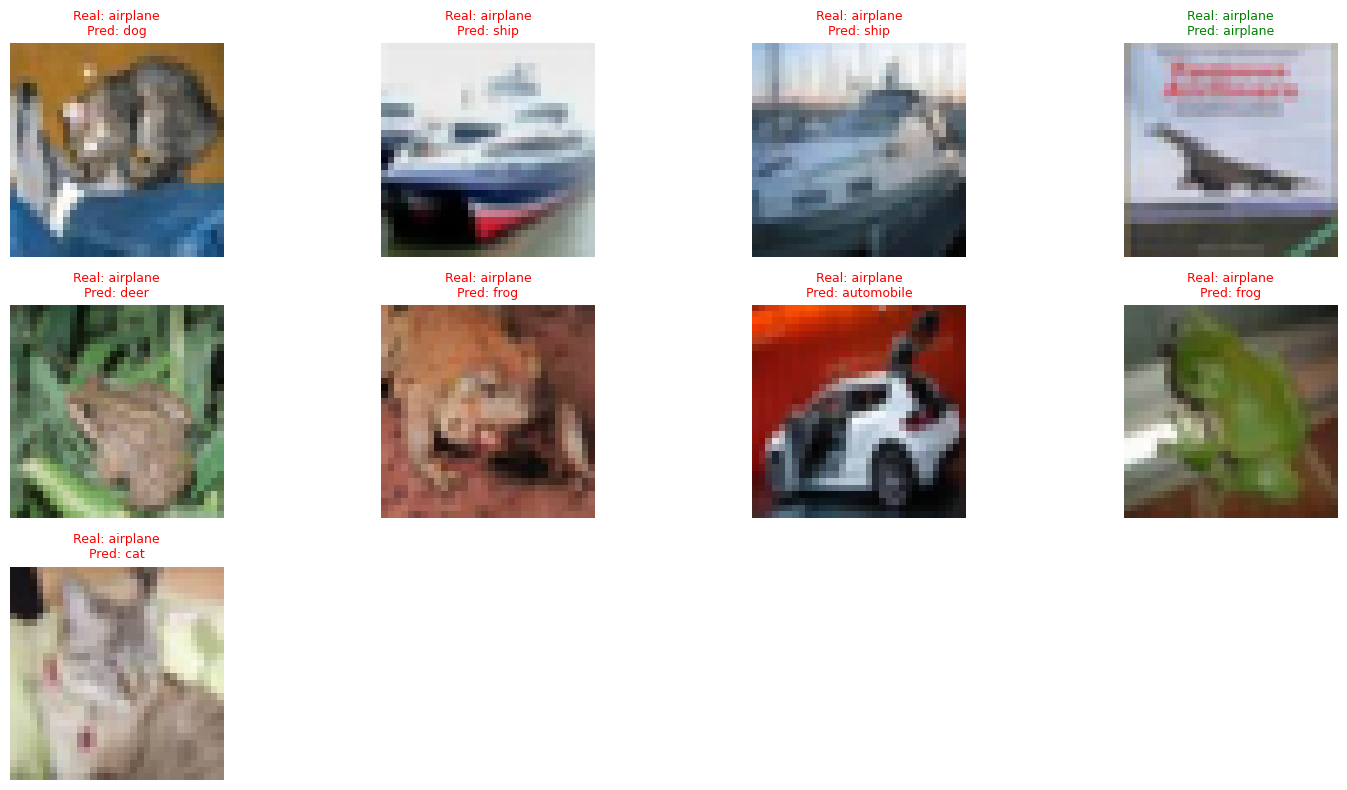

In [33]:
# Classes réelles
y_true = np.argmax(y_test, axis=1)

# Afficher 12 images
plt.figure(figsize=(15,8))

for i in range(9):
    plt.subplot(3,4,i+1)

    plt.imshow(X_test[i])

    true_label = classes[y_true[i]]
    pred_label = classes[y_perdicted_classes[i]]

    if true_label == pred_label:
        color = "green"
    else:
        color = "red"

    plt.title(
        f"Real: {true_label}\nPred: {pred_label}",
        color=color,
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

Pizza_Steak

In [ ]:
import zipfile

# Download zip file of pizza_steak images
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip

# Unzip the downloaded file
zip_ref = zipfile.ZipFile("pizza_steak.zip", "r")
zip_ref.extractall()
zip_ref.close()


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
pizza_images = mpimg.imread("/content/pizza_steak/test/pizza/1001116.jpg")
steak_images = mpimg.imread("/content/pizza_steak/test/steak/100274.jpg")
plt.imshow(pizza_images)
plt.show()
plt.imshow(steak_images)
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)
train_dir = '/content/pizza_steak/train'
test_dir = '/content/pizza_steak/test'

train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=(224, 224),
                                               batch_size=32,
                                               class_mode="binary",
                                               seed=42)
test_data = test_datagen.flow_from_directory(test_dir,
                                             target_size=(224, 224),
                                             batch_size=32,
                                             class_mode="binary",
                                             seed=42)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

model_0 = Sequential([
    Flatten(input_shape=(224, 224, 3)),
    Dense(4, activation='relu'),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [ ]:
model_0.compile(loss="binary_crossentropy",
              optimizer='Adam',
              metrics=["accuracy"])

In [ ]:
history_0 = model_0.fit(train_data, epochs=50, validation_data=test_data, verbose=1)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
from tensorflow.keras.regularizers import l2
model_1 = Sequential([
    Conv2D(10, 3, input_shape=(224, 224, 3), kernel_regularizer = l2(0.02)),
    MaxPool2D(),
    Conv2D(10, 3, activation='relu', kernel_regularizer = l2(0.02)),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation='sigmoid')
])

In [ ]:
model_1.compile(loss="binary_crossentropy",
              optimizer='Adam',
              metrics=["accuracy"])

In [ ]:
history_1 = model_1.fit(train_data, epochs=5, validation_data=test_data, verbose=1)

In [ ]:
acc = history_1.history['accuracy']
val_acc = history_1.history['val_accuracy']
loss = history_1.history['loss']
val_loss = history_1.history['val_loss']
epochs_range = range(len(acc))
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Acc')
plt.plot(epochs_range, val_acc, label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

#### Model_with_L2

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
from tensorflow.keras.regularizers import l2
model_2 = Sequential([
    Conv2D(10, 3, input_shape=(224, 224, 3), kernel_regularizer = l2(0.02)),
    MaxPool2D(),
    Conv2D(10, 3, activation='relu', kernel_regularizer = l2(0.02)),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation='sigmoid')
])

In [ ]:
model_2.compile(loss="binary_crossentropy",
              optimizer='Adam',
              metrics=["accuracy"])

In [ ]:
history_2 = model_2.fit(train_data, epochs=5, validation_data=test_data, verbose=1)

In [ ]:
acc = history_2.history['accuracy']
val_acc = history_2.history['val_accuracy']
loss = history_2.history['loss']
val_loss = history_2.history['val_loss']
epochs_range = range(len(acc))
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Acc')
plt.plot(epochs_range, val_acc, label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
model_vgg = tf.keras.Sequential()

# Bloc 1
model_vgg.add(Conv2D(64, 3, activation='relu', input_shape=(224, 224, 3)))
model_vgg.add(Conv2D(64, 3, activation='relu'))
model_vgg.add(MaxPool2D(2))

# Bloc 2
model_vgg.add(Conv2D(128, 3, activation='relu'))
model_vgg.add(Conv2D(128, 3, activation='relu'))
model_vgg.add(MaxPool2D(2))

# Bloc 3
model_vgg.add(Conv2D(256, 3, activation='relu'))
model_vgg.add(Conv2D(256, 3, activation='relu'))
model_vgg.add(Conv2D(256, 3, activation='relu'))
model_vgg.add(MaxPool2D(2))

# Bloc 4
model_vgg.add(Conv2D(512, 3, activation='relu'))
model_vgg.add(Conv2D(512, 3, activation='relu'))
model_vgg.add(Conv2D(512, 3, activation='relu'))
model_vgg.add(MaxPool2D(2))

# Bloc 5
model_vgg.add(Conv2D(512, 3, activation='relu'))
model_vgg.add(Conv2D(512, 3, activation='relu'))
model_vgg.add(Conv2D(512, 3, activation='relu'))
model_vgg.add(MaxPool2D(2))

# Classifieur
model_vgg.add(Flatten())
model_vgg.add(Dense(4096, activation='relu'))
model_vgg.add(Dense(4096, activation='relu'))
model_vgg.add(Dense(1, activation='sigmoid'))  # Pour classification binaire


In [ ]:
model_vgg.compile(loss="binary_crossentropy",
              optimizer='Adam',
              metrics=["accuracy"])

In [ ]:
history_vgg = model_vgg.fit(train_data, epochs=50, validation_data=test_data, verbose=1)

In [ ]:
!ls pizza_steak


In [ ]:
import matplotlib.image as mmpimg
image_pizza = mmpimg.imread('/content/pizza_steak/train/pizza/1008941.jpg')
image_steak = mmpimg.imread('/content/pizza_steak/train/steak/1000205.jpg')

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(image_pizza)
plt.show()
plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(image_pizza)
plt.title("Pizza")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image_steak)
plt.title("Steak")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)
#le chemain des dossier d'images
train_dir = "/content/pizza_steak/train/"
test_dir = "/content/pizza_steak/test/"

train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=(224, 224),
                                               batch_size=32,
                                               class_mode="binary",
                                               seed=42)
test_data = test_datagen.flow_from_directory(test_dir,
                                             target_size=(224, 224),
                                             batch_size=32,
                                             class_mode="binary",
                                             seed=42)

In [ ]:
#creation de model avec sequential
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Flatten
model_0 = Sequential([
    Flatten(input_shape=(224, 224, 3)),
    Dense(4, activation='relu'),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid')
    ])

In [ ]:
# compiter le modèle
model_0.compile(loss="binary_crossentropy",
              optimizer='Adam',
              metrics=["accuracy"])

In [ ]:
history_0 = model_0.fit(train_data, epochs=50, validation_data=test_data, verbose=1)

In [ ]:
model_0.summary()

In [ ]:
from tensorflow.keras.optimizers import SGD
model_1 = Sequential([
    Flatten(input_shape=(224, 224, 3)),
    Dense(500, activation='relu'),
    Dense(400, activation='relu'),
    Dense(100, activation='relu'),
    Dense(1, activation='sigmoid')
    ])
# compiter le modèle
model_1.compile(loss="binary_crossentropy",
              optimizer='sgd',
              metrics=["accuracy"])
history_1 = model_1.fit(train_data, epochs=50, validation_data=test_data, verbose=1)

In [ ]:
model_1.summary()

In [ ]:
#pour un modèle CNN
from tensorflow.keras.layers import Conv2D, MaxPool2D
model_2 = Sequential([
    Conv2D(10, 3, input_shape=(224, 224, 3)),
    Conv2D(10, 3, activation='relu'),
    Flatten(),
    Dense(1, activation='sigmoid')
])
# compiter le modèle
model_2.compile(loss="binary_crossentropy",
              optimizer='adam',
              metrics=["accuracy"])
history_2 = model_2.fit(train_data, epochs=50, validation_data=test_data, verbose=1)

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(64,3,input_shape=(224,224,3)),
    tf.keras.layers.Conv2D(64,3),
    tf.keras.layers.MaxPool2D(2),

    tf.keras.layers.Conv2D(128,3),
    tf.keras.layers.Conv2D(128,3),
    tf.keras.layers.MaxPool2D(2),

    tf.keras.layers.Conv2D(256,3),
    tf.keras.layers.Conv2D(256,3),
    tf.keras.layers.Conv2D(256,3),
    tf.keras.layers.MaxPool2D(2),

    tf.keras.layers.Conv2D(512,3),
    tf.keras.layers.Conv2D(512,3),
    tf.keras.layers.Conv2D(512,3),
    tf.keras.layers.MaxPool2D(2),

    tf.keras.layers.Conv2D(512,3),
    tf.keras.layers.Conv2D(512,3),
    tf.keras.layers.Conv2D(512,3),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(4096),
    tf.keras.layers.Dense(4096),
    tf.keras.layers.Dense(1,activation="sigmoid")

])

model.compile(loss="binary_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

history = model.fit(train_data,
                    epochs=5,
                    steps_per_epoch=len(train_data),
                    validation_data=test_data,
                    validation_steps=len(test_data)
                    )

### Let's try with VGG  architecture


In [ ]:
# Build a VGG-style model from scratch
def build_vgg_like_model(input_shape=(224, 224, 3), num_classes=2):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(64, 3, activation='relu', padding='same', input_shape=input_shape),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),

        # Block 2
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),

        # Block 3
        layers.Conv2D(256, 3, activation='relu', padding='same'),
        layers.Conv2D(256, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),

        # Classification head
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Build and compile the model
model = build_vgg_like_model(num_classes=2)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=10)

# Plot results
def plot_history(hist):
    acc = hist.history['accuracy']
    val_acc = hist.history['val_accuracy']
    loss = hist.history['loss']
    val_loss = hist.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Acc')
    plt.plot(epochs_range, val_acc, label='Val Acc')
    plt.legend()
    plt.title('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.legend()
    plt.title('Loss')
    plt.show()

plot_history(history)


In [ ]:
def vgg16(inputshape0=(1000,1000,3),numclasses=20):
  model=Sequential()
  model_vgg.add(conv2D(64,3,activation=relu,inputshape=inputshape0))
  model_vgg.add(conv2D(64,3,activation=relu))
  model_vgg.add(maxpool2D)
  model_vgg.add(conv2D(128,3,activation=relu))
  model_vgg.add(conv2D(128,3,activation=relu))
  model_vgg.add(maxpool2D)
  model_vgg.add(conv2D(256,3,activation=relu))
  model_vgg.add(conv2D(256,3,activation=relu))
  model_vgg.add(maxpool2D)
  model_vgg.add(conv2D(512,3,activation=relu))
  model_vgg.add(conv2D(512,3,activation=relu))
  model_vgg.add(conv2D(512,3,activation=relu))
  model_vgg.add(maxpool2D)
  model_vgg.add(conv2D(512,3,activation=relu))
  model_vgg.add(conv2D(512,3,activation=relu))
  model_vgg.add(conv2D(512,3,activation=relu))
  model_vgg.add(maxpool2D)
  model_vgg.add(flatten())
  model_vgg.add(Dense(4096,activation=relu))
  model_vgg.add(Dense(4096,activation=relu))
  model_vgg.add(Dense(1000,activation=relu))
  model_vgg.add(Dense(numclasses,activation=softmax))
  return model

In [ ]:
import tensorflow_datasets as tfds
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D
from tensorflow.keras.applications import EfficientNetB0, VGG16

In [ ]:
(train_ds, val_ds, test_ds), ds_info = tfds.load(
    "tf_flowers",
    split=["train[:80%]", "(train[80%:90%])", "train[90%:]"],
